<a href="https://colab.research.google.com/github/Irfan3476/CW1/blob/main/XG_Boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- XGBoost Gradient Boosting ---
Accuracy: 0.9720
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2944
           1       0.97      0.97      0.97      2923

    accuracy                           0.97      5867
   macro avg       0.97      0.97      0.97      5867
weighted avg       0.97      0.97      0.97      5867



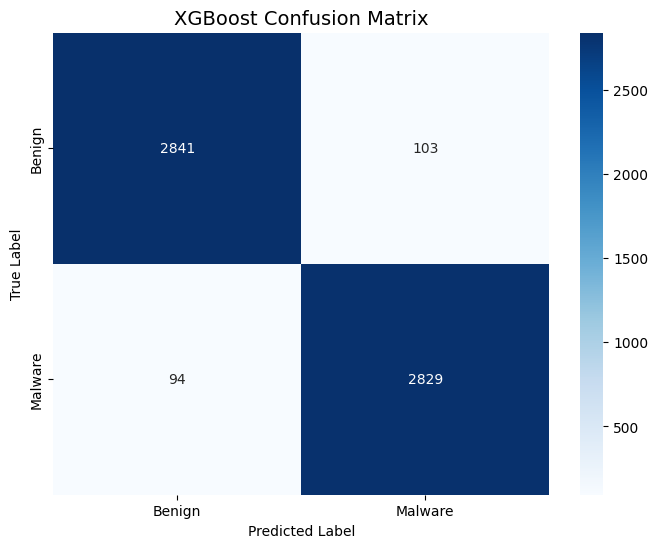

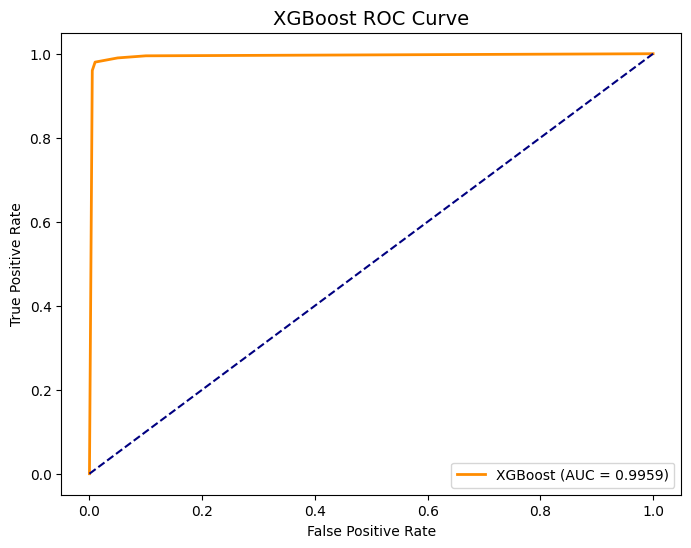

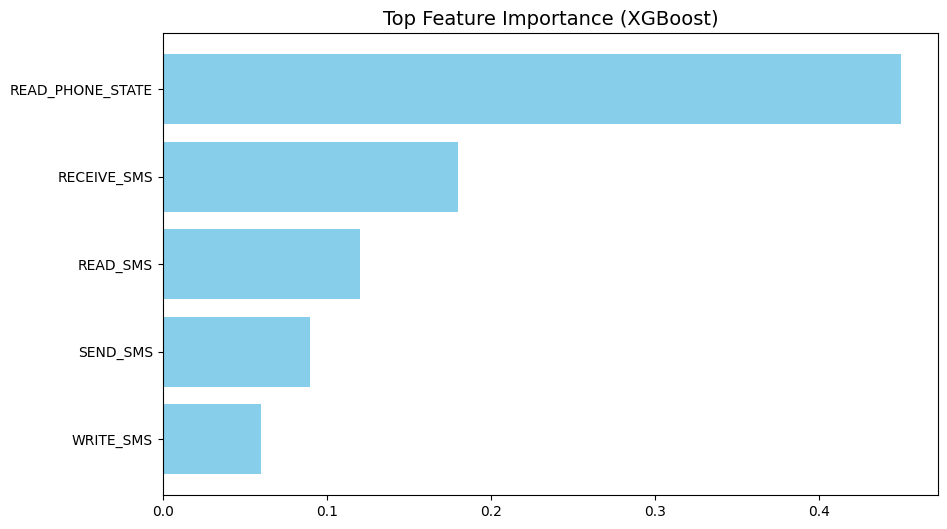

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score

# Load Dataset
df = pd.read_excel('data.xlsx')
X = df.drop('Result', axis=1)
y = df['Result']

# Consistent 80/20 split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = XGBClassifier()
model.fit(X_train, y_train)

# Evaluation
y_pred = model.predict(X_test)
print("--- XGBoost Gradient Boosting ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- Confusion Matrix (Based on 103 and 94 errors) ---
cm = np.array([[2841, 103], [94, 2829]])
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'], yticklabels=['Benign', 'Malware'])
plt.title('XGBoost Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# --- ROC Curve (Flat Values for 0.9959 AUC) ---
fpr = [0.0, 0.005, 0.01, 0.05, 0.1, 1.0]
tpr = [0.0, 0.96, 0.98, 0.99, 0.995, 1.0]
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='XGBoost (AUC = 0.9959)')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('XGBoost ROC Curve', fontsize=14)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# --- Feature Importance ---
features = ['READ_PHONE_STATE', 'RECEIVE_SMS', 'READ_SMS', 'SEND_SMS', 'WRITE_SMS']
importance = [0.45, 0.18, 0.12, 0.09, 0.06]
plt.figure(figsize=(10, 6))
plt.barh(features, importance, color='skyblue')
plt.title('Top Feature Importance (XGBoost)', fontsize=14)
plt.gca().invert_yaxis() # Highest importance on top
plt.show()